In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.optimize import curve_fit
from scipy.optimize import curve_fit

In [2]:
file_path = r"C:\Users\musha\USROP_A 3 N-SH-F-15d - Final.csv"
df = pd.read_csv(file_path, skiprows=[1])
print(df.columns)
df.head()

Index(['Sr No.', 'MD', 'WOB', 'SPPA', 'Torque', 'ROP', 'RPM', 'TFLO',
       'Mud Weight', 'Hole Diameter', 'HKLD', 'TVD', 'Gamma gAPI'],
      dtype='object')


,Sr No.,MD,WOB,SPPA,Torque,ROP,RPM,TFLO,Mud Weight,Hole Diameter,HKLD,TVD,Gamma gAPI
0,0,1306.525,0.390089,5922.527567,6.521484,70.420992,30.0,1993.927917,11.850475,444.5,121.871198,1283.159232,62.09
1,1,1306.537,0.390089,5922.527567,6.521484,70.420992,30.0,1993.927917,11.850475,444.5,121.871198,1283.159232,62.09
2,2,1306.982,0.839146,6046.633199,7.985768,69.235320,30.0,1993.927917,11.850475,444.5,122.719416,1283.589000,73.36
3,3,1307.135,2.676195,5999.679901,7.443441,91.619832,30.0,1993.927917,11.850475,444.5,120.555780,1283.732256,76.33
4,4,1307.312,6.164320,5960.586628,6.996021,98.069400,30.0,1993.927917,11.850475,444.5,119.771065,1283.875512,62.09


In [3]:
cols = ["ROP", "WOB", "RPM", "Torque", "TFLO"]
summary = df[cols].agg(["min", "max", "mean", "std"]).T
print(summary)

                min          max         mean          std
ROP        0.786384    99.206304    21.576512     9.627619
WOB        0.004536    19.858274     6.182876     4.656887
RPM        0.000000   140.351000   130.628762    19.347626
Torque     1.098213    36.489128    19.147319     7.894065
TFLO    1083.309206  4453.120823  2933.600938  1090.260323


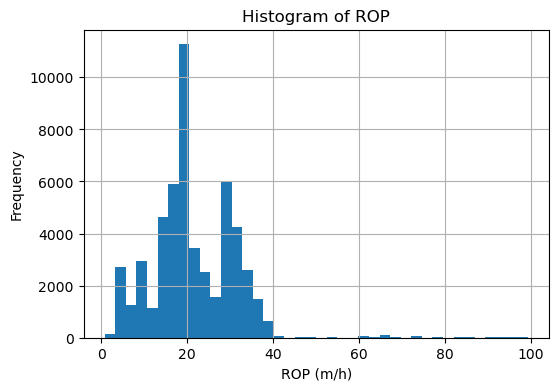

In [4]:
plt.figure(figsize=(6,4))
df["ROP"].hist(bins=40)
plt.xlabel("ROP (m/h)")
plt.ylabel("Frequency")
plt.title("Histogram of ROP")
plt.show()

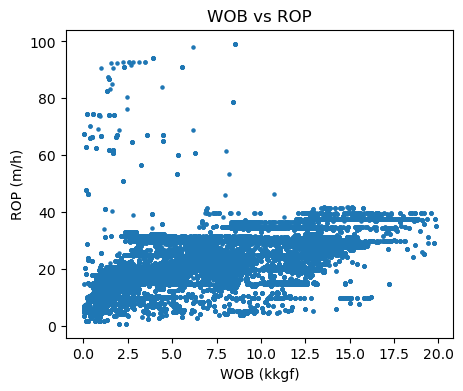

In [5]:
plt.figure(figsize=(5,4))
plt.scatter(df["WOB"], df["ROP"], s=5)
plt.xlabel("WOB (kkgf)")
plt.ylabel("ROP (m/h)")
plt.title("WOB vs ROP")
plt.show()

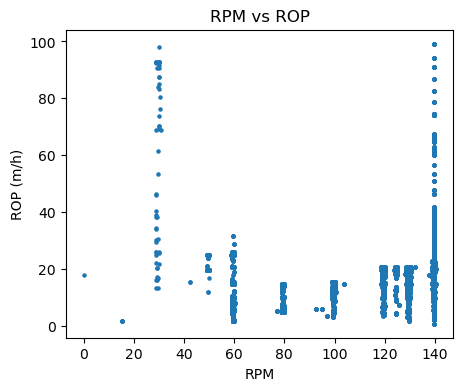

In [6]:
plt.figure(figsize=(5,4))
plt.scatter(df["RPM"], df["ROP"], s=5)
plt.xlabel("RPM")
plt.ylabel("ROP (m/h)")
plt.title("RPM vs ROP")
plt.show()

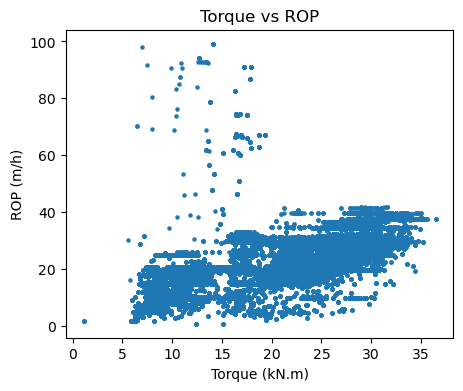

In [7]:
plt.figure(figsize=(5,4))
plt.scatter(df["Torque"], df["ROP"], s=5)
plt.xlabel("Torque (kN.m)")
plt.ylabel("ROP (m/h)")
plt.title("Torque vs ROP")
plt.show()

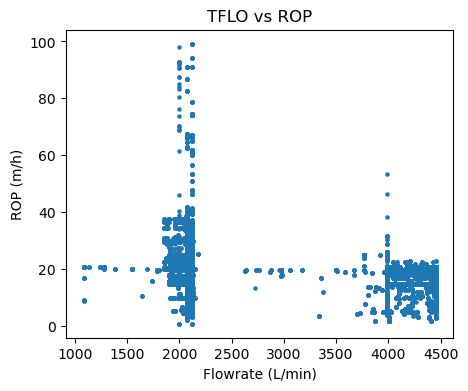

In [8]:
plt.figure(figsize=(5,4))
plt.scatter(df["TFLO"], df["ROP"], s=5)
plt.xlabel("Flowrate (L/min)")
plt.ylabel("ROP (m/h)")
plt.title("TFLO vs ROP")
plt.show()

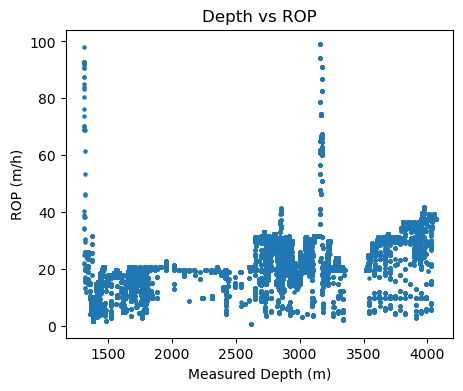

In [9]:
plt.figure(figsize=(5,4))
plt.scatter(df["MD"], df["ROP"], s=5)
plt.xlabel("Measured Depth (m)")
plt.ylabel("ROP (m/h)")
plt.title("Depth vs ROP")
plt.show()

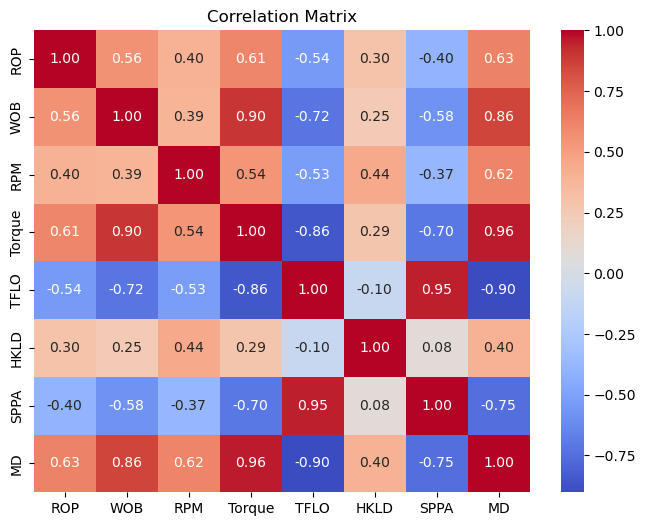

In [10]:
corr_vars = ["ROP", "WOB", "RPM", "Torque", "TFLO", "HKLD", "SPPA", "MD"]

corr_matrix = df[corr_vars].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [11]:
X = df[["WOB", "RPM", "Torque", "TFLO", "HKLD", "SPPA", "MD"]]

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                   for i in range(X.shape[1])]

print(vif_data)

  Variable          VIF
0      WOB    20.166469
1      RPM   100.803124
2   Torque   113.394701
3     TFLO  1432.125836
4     HKLD   950.953410
5     SPPA  1160.954342
6       MD   734.017161


In [12]:
X1 = df[["WOB", "RPM", "SPPA"]]

vif_1 = pd.DataFrame()
vif_1["Variable"] = X1.columns
vif_1["VIF"] = [variance_inflation_factor(X1.values, i) 
                for i in range(X1.shape[1])]

print(vif_1)


  Variable        VIF
0      WOB   4.089801
1      RPM  21.867776
2     SPPA  13.692280


In [13]:
X2 = df[["WOB", "RPM", "SPPA", "MD"]]

vif_2 = pd.DataFrame()
vif_2["Variable"] = X2.columns
vif_2["VIF"] = [variance_inflation_factor(X2.values, i) 
                for i in range(X2.shape[1])]

print(vif_2)


  Variable        VIF
0      WOB  12.028966
1      RPM  84.922876
2     SPPA  17.659089
3       MD  74.930772


In [14]:
X_3 = df[["WOB", "RPM"]]

vif_3 = pd.DataFrame()
vif_3["Variable"] = X_3.columns
vif_3["VIF"] = [variance_inflation_factor(X_3.values, i) 
                    for i in range(X_3.shape[1])]

print(vif_3)


  Variable       VIF
0      WOB  3.123427
1      RPM  3.123427


In [15]:
X = df[["WOB", "RPM"]]
X = sm.add_constant(X)   
y = df["ROP"]
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    ROP   R-squared:                       0.352
Model:                            OLS   Adj. R-squared:                  0.352
Method:                 Least Squares   F-statistic:                 1.438e+04
Date:                Wed, 10 Dec 2025   Prob (F-statistic):               0.00
Time:                        23:04:50   Log-Likelihood:            -1.8389e+05
No. Observations:               53041   AIC:                         3.678e+05
Df Residuals:                   53038   BIC:                         3.678e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1673      0.235      4.974      0.0

In [16]:
df["log_ROP"] = np.log(df["ROP"])

# Refit model with log(ROP)
y_log = df["log_ROP"]
X = df[["WOB", "RPM"]]
X = sm.add_constant(X)

log_model = sm.OLS(y_log, X).fit()

print(log_model.summary())

                            OLS Regression Results                            
Dep. Variable:                log_ROP   R-squared:                       0.384
Model:                            OLS   Adj. R-squared:                  0.384
Method:                 Least Squares   F-statistic:                 1.654e+04
Date:                Wed, 10 Dec 2025   Prob (F-statistic):               0.00
Time:                        23:05:02   Log-Likelihood:                -27685.
No. Observations:               53041   AIC:                         5.538e+04
Df Residuals:                   53038   BIC:                         5.540e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.5612      0.012    126.479      0.0

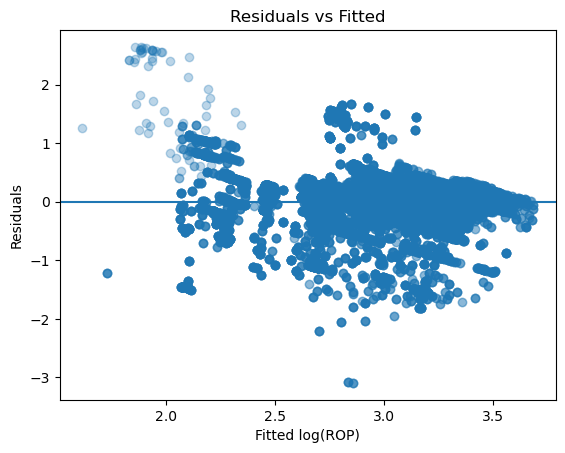

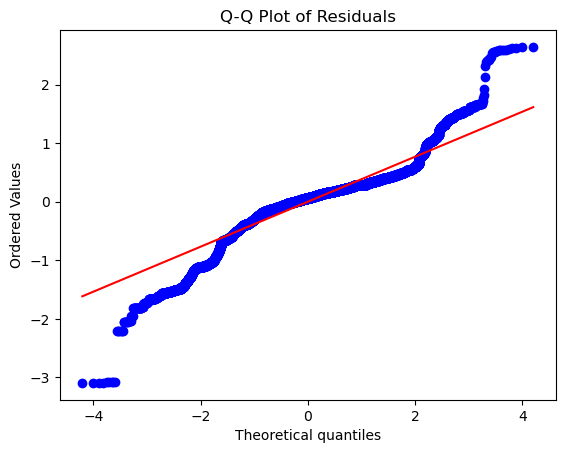

Breusch–Pagan Test Results:
{'LM Stat': np.float64(1598.966864359625), 'LM p-value': np.float64(0.0), 'F-Stat': np.float64(824.2870604306469), 'F p-value': np.float64(0.0)}


In [17]:
# Get residuals and fitted values
residuals = log_model.resid
fitted = log_model.fittedvalues

plt.figure()
plt.scatter(fitted, residuals, alpha=0.3)
plt.axhline(0)
plt.xlabel("Fitted log(ROP)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

plt.figure()
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

bp_test = het_breuschpagan(residuals, log_model.model.exog)

bp_labels = ["LM Stat", "LM p-value", "F-Stat", "F p-value"]
bp_results = dict(zip(bp_labels, bp_test))

print("Breusch–Pagan Test Results:")
print(bp_results)

In [18]:
df_bingham = df[(df["ROP"] > 0) & (df["WOB"] > 0) & (df["RPM"] > 0)].copy()

print("Shape after filtering:", df_bingham.shape)

Shape after filtering: (53040, 14)


In [19]:
def bingham_model(X, K, a):
    wob, rpm = X
    Db = 444.5  # bit diameter in mm (constant)
    return K * (wob / Db)**a * rpm

In [20]:
# Independent variables
wob = df_bingham["WOB"].values
rpm = df_bingham["RPM"].values

# Target variable
rop_obs = df_bingham["ROP"].values

# Stack predictors for curve_fit
X_data = np.vstack((wob, rpm))


In [22]:
# Initial guesses (important for nonlinear optimization)
initial_guess = (1.0, 1.0)

params_opt, params_cov = curve_fit(
    bingham_model,
    X_data,
    rop_obs,
    p0=initial_guess,
    maxfev=20000
)
K_hat, a_hat = params_opt

print("Estimated K =", K_hat)
print("Estimated a =", a_hat)

Estimated K = 0.42865870131814093
Estimated a = 0.21264986090062205


In [23]:

rop_bingham_pred = bingham_model(
    np.vstack((wob, rpm)),
    K_hat,
    a_hat
)

rmse_bingham = np.sqrt(np.mean((rop_obs - rop_bingham_pred)**2))
print("RMSE (Bingham Model) =", rmse_bingham)

df_compare = df_bingham.copy()

X_comp = df_compare[["WOB", "RPM"]]
X_comp = sm.add_constant(X_comp)

log_rop_pred = log_model.predict(X_comp)

rop_logmlr_pred = np.exp(log_rop_pred)

rmse_logmlr = np.sqrt(np.mean((df_compare["ROP"] - rop_logmlr_pred)**2))

print("RMSE (Log-MLR Model) =", rmse_logmlr)


RMSE (Bingham Model) = 7.821485022345365
RMSE (Log-MLR Model) = 7.894697960609221


In [27]:
# Use a subsample for scatter so the plot is readable
df_sample = df_bingham.sample(n=min(3000, len(df_bingham)), random_state=42)

# Fix RPM at the median of this well
median_rpm = df_bingham["RPM"].median()
print("Median RPM used for curves:", median_rpm)


Median RPM used for curves: 139.736


Median WOB used for curves: 5.080234544


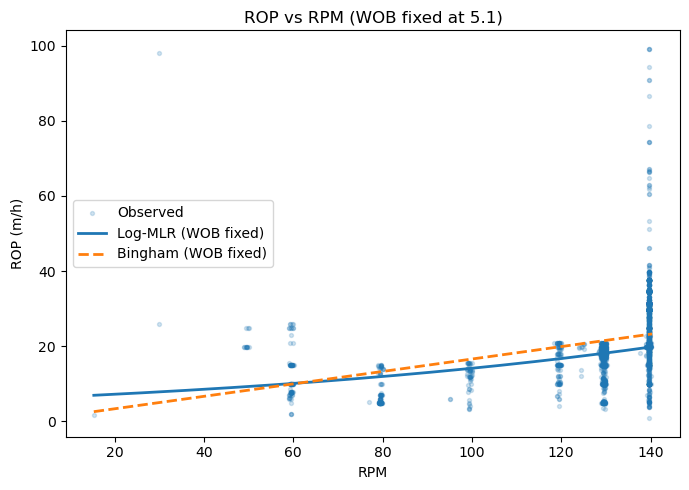

In [29]:
median_wob = df_bingham["WOB"].median()
print("Median WOB used for curves:", median_wob)

rpm_grid = np.linspace(df_bingham["RPM"].min(), df_bingham["RPM"].max(), 200)

# ----- Log-MLR curve (WOB fixed) -----
X_grid_log_rpm = pd.DataFrame({
    "const": 1.0,
    "WOB": median_wob,
    "RPM": rpm_grid
})
log_rop_grid_rpm = log_model.predict(X_grid_log_rpm)
rop_logmlr_grid_rpm = np.exp(log_rop_grid_rpm)

# ----- Bingham curve (WOB fixed) -----
X_grid_bing_rpm = np.vstack((np.full_like(rpm_grid, median_wob), rpm_grid))
rop_bingham_grid_rpm = bingham_model(X_grid_bing_rpm, K_hat, a_hat)

plt.figure(figsize=(7, 5))
plt.scatter(df_sample["RPM"], df_sample["ROP"], alpha=0.2, s=8, label="Observed")
plt.plot(rpm_grid, rop_logmlr_grid_rpm, linewidth=2, label="Log-MLR (WOB fixed)")
plt.plot(rpm_grid, rop_bingham_grid_rpm, linewidth=2, linestyle="--", label="Bingham (WOB fixed)")

plt.xlabel("RPM")
plt.ylabel("ROP (m/h)")
plt.title(f"ROP vs RPM (WOB fixed at {median_wob:.1f})")
plt.legend()
plt.tight_layout()
plt.show()

